# 📊 Trabalho de Clusterização em 3D com KMeans

## Disciplina: Aprendizado de Máquina Não Supervisionado  
**Curso:** Tecnologia em Ciência de Dados  
**Instituição:** Faculdade de Tecnologia e Inovação Senac DF  
**Professor:** Rogério Gomes Lopes  

**Objetivo:** Analisar a **Distribuição de Renda por Centis no Brasil** a partir de dados **granulares por Estado, Região e Ano**,  
por meio de **clusterização não supervisionada (KMeans)**, utilizando **3 variáveis contínuas** e visualização em **3D**.  
O propósito é identificar **padrões de renda, patrimônio e carga tributária** entre diferentes grupos socioeconômicos,  
explorando como esses perfis se distribuem entre estados e regiões, bem como sua evolução temporal.

---

### 👨‍🎓 Alunos
- Anderson de Matos Guimarães  
- Gustavo Stefano Thomazinho  
- Renan Ost  

---

📅 **Semestre:** 4º semestre (2025/2)  


## 1. Business Understanding

O presente trabalho busca analisar a **Distribuição de Renda por Centis no Brasil**, utilizando técnicas de 
**Aprendizado de Máquina Não Supervisionado**, com foco na **clusterização em 3D via KMeans**.

A base de dados disponibilizada pela Receita Federal apresenta informações **granulares** de renda declarada, 
discriminadas por:

- **Ano-calendário** (período de referência da declaração);
- **Ente Federativo (UF)**;
- **Centil de Renda** (100 divisões iguais da população, sendo que o centésimo é subdividido em extratos mais finos).

---

### 🔎 O que é um Centil?

Na base da Receita Federal, os declarantes são divididos em **100 grupos de igual tamanho**, chamados **centis**, 
a partir da **Renda Tributável Bruta (RTB)**:

- O **1º centil** corresponde ao 1% da população com menor renda declarada.  
- O **100º centil** corresponde ao 1% mais rico, que é subdividido em 10 partes iguais; e a última dessas (o 0,1% do topo) 
é novamente dividida em 10 partes, para discriminar com mais detalhe o **extrato superior da renda**.

Essa metodologia, baseada no conceito estatístico de **percentis**, permite analisar a distribuição de renda de forma 
**granular e comparável**, garantindo que cada centil represente a mesma quantidade de contribuintes.  
A subdivisão do centésimo centil é uma decisão metodológica da Receita Federal para melhor captar a 
**alta concentração de renda no topo**.

---

### Variáveis disponíveis na base
Para cada (Ano × UF × Centil), são informados valores como:

- **Rendimentos Tributáveis** (soma, limite, acumulada);  
- **Rendimentos Sujeitos à Tributação Exclusiva**;  
- **Rendimentos Isentos** (dividendos, Simples, outros);  
- **Despesas Dedutíveis** (saúde, educação, previdência, pensão, etc.);  
- **Imposto Devido**;  
- **Bens e Direitos** (imóveis, móveis, financeiros, outros);  
- **Dívidas e Ônus**.  

---

### 🎯 Objetivo da Análise
O objetivo é **identificar padrões de desigualdade econômica no Brasil**, por meio da clusterização de observações 
granulares (Centil × UF × Ano), utilizando **3 variáveis contínuas derivadas**:

1. **Renda Total** = Rendimentos Tributáveis + Exclusivos + Isentos  
2. **Patrimônio Líquido** = Bens Totais – Dívidas e Ônus  
3. **Carga Tributária Efetiva** = Imposto Devido / Renda Total  

---

### Questões de análise
- Quais perfis socioeconômicos são revelados pelos clusters?  
- Como esses clusters se distribuem entre **estados** e **regiões**?  
- Há diferenças significativas quando comparamos **anos distintos** (análise temporal)?  
- Os clusters ajudam a revelar **padrões de desigualdade de renda, patrimônio e carga tributária** no Brasil?


## 2. Data Understanding

Nesta etapa buscamos compreender a estrutura do dataset original, sua granularidade e o significado de suas variáveis.  
O objetivo é garantir que conhecemos bem os dados antes de realizar qualquer preparação ou modelagem.

---

### 📂 Dataset utilizado
A base **Distribuição de Renda por Centis** é disponibilizada pela Receita Federal.  
Cada linha corresponde a uma combinação de:

- **Ano-calendário** (período da declaração);  
- **Ente Federativo (UF)**;  
- **Centil de Renda** (100 divisões iguais da população com base na Renda Tributável Bruta).  

Ou seja, temos dados **granulares** por **ano, estado e centil**, o que permite uma análise detalhada da distribuição de renda no Brasil.

---

### 📖 Principais variáveis (segundo o dicionário de dados)
Algumas variáveis relevantes, extraídas do dicionário da Receita Federal:contentReference[oaicite:0]{index=0}, são:

- **Ano-calendário:** ano a que se refere a declaração.  
- **Ente Federativo:** estado (UF) ao qual os dados se referem.  
- **Centil:** grupo que representa 1% dos declarantes ordenados pela Renda Tributável Bruta.  
- **Rendimentos Tributáveis – Soma da RTB (R$ mi):** total da renda tributável bruta dentro do centil.  
- **Rendimentos Sujeitos à Tributação Exclusiva (R$ mi):** rendimentos sujeitos à tributação exclusiva e definitiva.  
- **Rendimentos Isentos (R$ mi):** incluem dividendos, Simples e outros rendimentos isentos.  
- **Despesas Dedutíveis (R$ mi):** previdência, dependentes, instrução, médicas, pensão, livro-caixa.  
- **Imposto Devido (R$ mi):** total de imposto calculado para o centil.  
- **Bens e Direitos (R$ mi):** imóveis, móveis, financeiros, outros.  
- **Dívidas e Ônus (R$ mi):** valor total de dívidas declaradas.  

Essas variáveis servirão de base para criarmos as **três variáveis derivadas** que serão utilizadas na clusterização.

---

### 🔎 Exploração inicial do dataset
Antes de criar variáveis derivadas, vamos observar o dataset original.


In [3]:
# ================================
# Carregar o dataset original
# ================================
import pandas as pd

# Como o arquivo está no mesmo diretório do notebook:
csv_path = "distribuicao-renda.csv"

# Em alguns casos o separador pode ser ";", por isso testamos
df = pd.read_csv(csv_path, sep=";", low_memory=False)


In [4]:
print("Dimensões do dataset:", df.shape)


Dimensões do dataset: (46350, 24)


In [5]:
# Primeiras linhas do dataset
df.head()


,Ano-calendário,Ente Federativo,Centil,Quantidade de Contribuintes,Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões],Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões],Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões],Rendimentos Tributaveis - Média da RTB do Centil [R$],Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões],Rendimentos Isentos - Lucros e dividendos [R$ milhões],...,Despesas Dedutíveis - Instrução [R$ milhões],Despesas Dedutíveis - Médicas [R$ milhões],Despesas Dedutíveis - Pensão Alimentícia [R$ milhões],Despesas Dedutíveis - Livro-Caixa [R$ milhões],Imposto Devido [R$ milhões],Bens e Direitos - Imóveis [R$ milhões],Bens e Direitos - Móveis [R$ milhões],Bens e Direitos - Financeiros [R$ milhões],Bens e Direitos - Outros Bens e Direitos [R$ milhões],Dívidas e Ônus [R$ milhões]
0,2006,BRASIL,1,241.563,NaN,NaN,NaN,NaN,"235,61","481,27",...,NaN,NaN,NaN,NaN,"0,16","5.281,59","686,21","6.549,15","1.006,40","1.610,39"
1,2006,BRASIL,2,241.563,NaN,NaN,NaN,NaN,"208,74","483,44",...,NaN,NaN,NaN,NaN,"0,22","5.295,48","668,82","5.762,77","681,75","694,12"
2,2006,BRASIL,3,241.562,NaN,NaN,NaN,NaN,"219,96","459,87",...,NaN,NaN,NaN,NaN,"0,31","5.566,27","670,64","5.451,95","377,17","650,98"
3,2006,BRASIL,4,241.563,NaN,NaN,NaN,NaN,"257,01","481,93",...,NaN,NaN,NaN,NaN,"0,17","5.860,02","678,44","6.104,09","256,16","1.079,20"
4,2006,BRASIL,5,241.562,NaN,NaN,NaN,NaN,"249,88","464,23",...,NaN,NaN,NaN,NaN,"0,17","5.193,31","682,38","5.592,52","269,28","671,97"


📌 **Análise do head():**  
- Confirma a granularidade dos dados: cada linha corresponde a **Ano × Ente Federativo × Centil**.  
- Observa-se que o campo **Ente Federativo = BRASIL** representa o nível agregado nacional, que deverá ser removido
nas análises, pois o foco é a comparação por estados (UF).  
- Colunas principais visíveis: rendimentos tributáveis, exclusivos, isentos, despesas dedutíveis, imposto devido, bens e direitos, dívidas.  
- Valores em **milhões de R$** (atenção na interpretação dos números).  
- Alguns campos aparecem como `NaN` no agregado “Brasil”, reforçando a necessidade de filtrar apenas os dados de UF.  


In [6]:
# Últimas linhas do dataset
df.tail()


,Ano-calendário,Ente Federativo,Centil,Quantidade de Contribuintes,Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões],Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões],Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões],Rendimentos Tributaveis - Média da RTB do Centil [R$],Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões],Rendimentos Isentos - Lucros e dividendos [R$ milhões],...,Despesas Dedutíveis - Instrução [R$ milhões],Despesas Dedutíveis - Médicas [R$ milhões],Despesas Dedutíveis - Pensão Alimentícia [R$ milhões],Despesas Dedutíveis - Livro-Caixa [R$ milhões],Imposto Devido [R$ milhões],Bens e Direitos - Imóveis [R$ milhões],Bens e Direitos - Móveis [R$ milhões],Bens e Direitos - Financeiros [R$ milhões],Bens e Direitos - Outros Bens e Direitos [R$ milhões],Dívidas e Ônus [R$ milhões]
46345,2020,TO,100.6,169.0,"486.602,57","79,96","434,49","473.152,32","7,78","2,64",...,"0,44","3,2","0,94","2,29","16,12","185,25","16,75","61,71","13,29","27,73"
46346,2020,TO,100.7,169.0,"523.830,78","85,51",520,"505.995,90","8,91","3,38",...,"0,43","3,4","1,21","2,46","17,67","195,46","22,77","80,08","3,55","43,45"
46347,2020,TO,100.8,169.0,"589.084,62","93,48","613,49","553.159,76","11,9","12,9",...,"0,52","3,11","1,01","3,35","19,68","457,81","28,19","169,15","25,91","43,73"
46348,2020,TO,100.9,169.0,"749.691,30","110,74","724,23","655.252,33","6,82","12,17",...,"0,39","2,25","1,58","8,62","23,19","182,83","28,11","122,92","26,32","26,01"
46349,2020,TO,100.10,168.0,"18.277.661,84","238,8","963,03","1.421.432,54","904,35","16,15",...,"0,28","2,21","1,06","58,95","45,22","514,07","31,17","1.137,50","219,8","190,09"


📌 **Análise do tail():**  
- Confirma que o dataset cobre o período até **2020**.  
- Mostra registros do estado de **Tocantins (TO)** no **100º centil** subdividido (100.1 até 100.10).  
- Essa subdivisão é feita apenas no topo da distribuição para detalhar melhor a concentração de renda no 1% mais rico.  
- Diferentemente do `head()`, aqui não aparecem linhas agregadas como "BRASIL".  
- Os valores estão preenchidos, mas com magnitudes muito elevadas (na casa de milhões), evidenciando a concentração de renda no topo.  
- Não há linhas adicionais de “Total” ou agregados no final, apenas dados regulares.  


In [7]:
# ================================
# Estatísticas descritivas
# ================================
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Ano-calendário,46350.0,2013.000000,4.320540,2006.000,2009.000,2013.00,2017.000,2020.0
Quantidade de Contribuintes,46350.0,96.555265,197.999486,1.001,2.894,6.79,29.169,993.0


📌 **Análise do describe():**  
- O resumo estatístico (`describe()`) apresenta apenas duas variáveis: **Ano-calendário** e **Quantidade de Contribuintes**.  
- Isso acontece porque as demais colunas (valores de rendimentos, bens, dívidas etc.) foram carregadas como **texto (string)**,  
  já que utilizam **vírgula como separador decimal** e **ponto como separador de milhar**.  
- Portanto, o pandas não as reconhece inicialmente como numéricas, tratando-as como `object`.  
- Essa constatação é importante: mostra que será necessário realizar **ajustes e conversões de tipos de dados** na etapa de **Data Preparation**.  

➡️ Aqui, entretanto, nosso objetivo é apenas **entender o dataset original**:  
vemos que os anos variam de **2006 a 2020** e que a quantidade de contribuintes por centil está corretamente registrada,  
confirmando a granularidade da base.  


In [8]:
# Estrutura do dataset: tipos de dados e valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46350 entries, 0 to 46349
Data columns (total 24 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   Ano-calendário                                                               46350 non-null  int64  
 1   Ente Federativo                                                              46350 non-null  object 
 2   Centil                                                                       46350 non-null  object 
 3   Quantidade de Contribuintes                                                  46350 non-null  float64
 4   Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]      42935 non-null  object 
 5   Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]                 42935 non-null  object 
 6   Rendimentos Tributaveis - RTB Acumulad

📌 **Análise do info():**

- O dataset possui **46.350 registros** e **24 colunas**.  

### Tipos de dados
- **Numéricos:**
  - `Ano-calendário` → `int64`  
  - `Quantidade de Contribuintes` → `float64`
- **Categóricos (texto):**
  - `Ente Federativo` (UFs e o agregado "BRASIL")  
  - `Centil` (1 a 100, com subdivisões do 100º centil)  
- **Monetários (mas carregados como texto):**
  - 20 colunas, como *Rendimentos Tributáveis*, *Rendimentos Exclusivos*, *Rendimentos Isentos*, *Despesas Dedutíveis*, *Imposto Devido*, *Bens e Direitos*, *Dívidas e Ônus* → todas `object` (string), quando deveriam ser `float`.

### Valores ausentes (NaN)
- Diversas colunas monetárias têm menos de 46.350 registros válidos, o que indica **dados ausentes**:
  - `Imposto Devido` → 38.184 não nulos (~18% faltantes).  
  - `Livro-Caixa` → 39.593 não nulos (~15% faltantes).  
  - Outras colunas (dedutíveis, rendimentos tributáveis, etc.) também apresentam lacunas.  

### Problema principal
- O uso de **vírgula como separador decimal** e **ponto como separador de milhar** fez com que o pandas interpretasse 
as colunas monetárias como **texto (`object`)** em vez de numéricas.  
- Isso explica porque, no `describe()`, apenas duas colunas foram reconhecidas como numéricas.  

---

➡️ **Conclusão desta análise:**  
- O dataset bruto está coerente em estrutura, mas contém **problemas de tipos de dados** e **valores faltantes**.  
- Será necessário, na **Seção 3 (Data Preparation)**:
  1. Converter colunas monetárias para `float`.  
  2. Tratar valores ausentes.  
  3. Excluir agregados como "BRASIL".  
  4. Criar variáveis derivadas para a clusterização (Renda Total, Patrimônio Líquido, Carga Tributária).  


## 3. Data Preparation

Nesta etapa realizaremos a **preparação dos dados** para viabilizar a aplicação do algoritmo de **clusterização (KMeans)**.  
Como identificado na fase anterior (*Data Understanding*), o dataset apresenta:

- **Colunas monetárias carregadas como texto** (`object`), devido ao uso de vírgula como separador decimal e ponto como separador de milhar;  
- **Valores ausentes** em variáveis relevantes, como `Imposto Devido` e despesas dedutíveis;  
- **Linhas agregadas** para o nível "BRASIL", que não devem ser utilizadas na análise de estados (UF);  
- **Granularidade** baseada em (Ano × UF × Centil), que precisa ser preservada.

---

### 🎯 Objetivos da preparação
1. **Limpeza de dados:**
   - Remover linhas agregadas como "BRASIL".  
   - Tratar valores ausentes de forma adequada (remoção ou substituição).  

2. **Conversão de tipos:**
   - Transformar as colunas monetárias de `object` para `float`.  
   - Garantir que todos os valores estejam em formato numérico consistente (R$ milhões → `float`).  

3. **Criação das variáveis derivadas:**
   - **Renda Total** = Rendimentos Tributáveis + Exclusivos + Isentos  
   - **Patrimônio Líquido** = Bens Totais – Dívidas e Ônus  
   - **Carga Tributária Efetiva** = Imposto Devido / Renda Total  

4. **Seleção temporal:**
   - Para a análise inicial (fotografia), utilizar apenas o **ano mais recente** disponível.  
   - Posteriormente, explorar comparações temporais entre anos (evolução dos clusters).  

5. **Escalonamento:**
   - Aplicar **StandardScaler** para normalizar as variáveis contínuas, evitando distorções no KMeans.  

---

📌 Ao final desta etapa, teremos um **dataframe preparado para clusterização**, contendo apenas três variáveis contínuas 
(`Renda Total`, `Patrimônio Líquido`, `Carga Tributária`) mais as colunas de identificação (`Ano`, `UF`, `Centil`, `Região`).


In [9]:
# ================================
# Criação do dataframe de preparação
# ================================

# Mantemos o df original como dataset bruto
# Criamos uma cópia para começar a limpeza e preparação
df_prep = df.copy()

print("Dimensões do dataframe bruto:", df.shape)
print("Dimensões do dataframe para preparação:", df_prep.shape)


Dimensões do dataframe bruto: (46350, 24)
Dimensões do dataframe para preparação: (46350, 24)


📌 **Início da preparação dos dados:**

- Mantemos o `df` como **dataset bruto**, carregado diretamente do CSV.  
- Criamos uma cópia chamada `df_prep`, que será utilizada para **todas as etapas de preparação**:  
  - limpeza de linhas agregadas (ex.: "BRASIL");  
  - conversão das colunas monetárias para formato numérico (`float`);  
  - tratamento de valores ausentes;  
  - criação das variáveis derivadas (`Renda Total`, `Patrimônio Líquido`, `Carga Tributária`).  

➡️ Essa separação garante que possamos **comparar o dataset original com o preparado**, tornando o processo mais didático e reprodutível.


In [10]:
# ================================
# Remover linhas agregadas do Brasil
# ================================

print("Registros antes da limpeza:", df_prep.shape[0])

# Normaliza o texto para evitar diferenças de caixa/letras
df_prep = df_prep[df_prep["Ente Federativo"].str.upper() != "BRASIL"]

print("Registros após a limpeza:", df_prep.shape[0])
print("Entes federativos únicos:", df_prep["Ente Federativo"].nunique())
print("Lista de entes federativos:", df_prep["Ente Federativo"].unique())


Registros antes da limpeza: 46350
Registros após a limpeza: 44550
Entes federativos únicos: 27
Lista de entes federativos: ['AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT' 'PA'
 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']


📌 **Resultados da limpeza do agregado 'BRASIL':**

- O dataset original possuía **46.350 registros**.  
- Após a remoção das linhas com `Ente Federativo = BRASIL`, restaram **44.550 registros**.  
- O número de entes federativos únicos agora é **27**, correspondendo corretamente aos **26 estados brasileiros + Distrito Federal**.  
- A lista de UFs confirma a abrangência nacional:  
  `['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG',
   'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR',
   'RS', 'SC', 'SE', 'SP', 'TO']`

➡️ Com essa limpeza, garantimos que a análise seja feita apenas no nível estadual, mantendo a granularidade desejada para os **27 entes federativos**.


In [11]:
cols_monetarias = [
    'Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]',
    'Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]',
    'Rendimentos Tributaveis - RTB Acumulada do Centil [R$ milhões]',
    'Rendimentos Tributaveis - Média da RTB do Centil [R$]',
    'Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões]',
    'Rendimentos Isentos - Lucros e dividendos [R$ milhões]',
    'Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões]',
    'Rendimentos Isentos - Outros Rendimentos Isentos [R$ milhões]',
    'Despesas Dedutíveis - Previdência [R$ milhões]',
    'Despesas Dedutíveis - Dependentes [R$ milhões]',
    'Despesas Dedutíveis - Instrução [R$ milhões]',
    'Despesas Dedutíveis - Médicas [R$ milhões]',
    'Despesas Dedutíveis - Pensão Alimentícia [R$ milhões]',
    'Despesas Dedutíveis - Livro-Caixa [R$ milhões]',
    'Imposto Devido [R$ milhões]',
    'Bens e Direitos - Imóveis [R$ milhões]',
    'Bens e Direitos - Móveis [R$ milhões]',
    'Bens e Direitos - Financeiros [R$ milhões]',
    'Bens e Direitos - Outros Bens e Direitos [R$ milhões]',
    'Dívidas e Ônus [R$ milhões]'
]

🧾 Definição das Variáveis Monetárias

Embora esta célula não produza uma saída visível, ela cumpre um papel fundamental na organização do pipeline de preparação dos dados.

Aqui, é criada a lista cols_monetarias, que reúne todas as colunas que expressam valores financeiros (renda, despesas, patrimônio e dívidas) no dataset da Receita Federal.
Essa etapa funciona como um mapa de referência das variáveis monetárias, permitindo:

aplicar rotinas de conversão padronizada de texto para número (ex.: transformar "1.234,56" em 1234.56);

automatizar etapas futuras de limpeza, evitando repetição de código;

garantir reprodutibilidade, já que qualquer função que manipule valores financeiros poderá iterar diretamente sobre essa lista.

➡️ Em resumo, esta célula não executa transformações diretas sobre o DataFrame, mas prepara o ambiente para as etapas seguintes, onde as colunas monetárias serão efetivamente convertidas e tratadas

In [12]:
# ================================
# Conversão das colunas monetárias para float (com segurança)
# ================================

def to_float(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(".", "", regex=False)   # remove separador de milhar
              .str.replace(",", ".", regex=False), # troca vírgula decimal por ponto
        errors="coerce"  # valores inválidos viram NaN
    )

# Aplicar a conversão
for col in cols_monetarias:
    if col in df_prep.columns:
        df_prep[col] = to_float(df_prep[col])

# Conferir novamente
df_prep.info()


<class 'pandas.core.frame.DataFrame'>
Index: 44550 entries, 120 to 46349
Data columns (total 24 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   Ano-calendário                                                               44550 non-null  int64  
 1   Ente Federativo                                                              44550 non-null  object 
 2   Centil                                                                       44550 non-null  object 
 3   Quantidade de Contribuintes                                                  44550 non-null  float64
 4   Rendimentos Tributaveis - Limite Superior da RTB do Centil [R$ milhões]      41250 non-null  float64
 5   Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]                 41250 non-null  float64
 6   Rendimentos Tributaveis - RTB Acumulada d

### 🔢 Conversão das Colunas Monetárias para Tipo Numérico (`float`)

Nesta etapa, convertemos todas as variáveis monetárias — originalmente armazenadas como **texto** (strings com separadores de milhar e vírgula decimal) — para o tipo **numérico (`float64`)**, que permite cálculos e análises quantitativas.

#### 🧠 Racional técnico:
- O dataset da Receita Federal apresenta valores no formato brasileiro, com **pontos como separadores de milhar** e **vírgulas como separadores decimais**.  
- O Python, por padrão, interpreta **ponto como separador decimal**, por isso é necessário um pré-processamento para evitar erros de conversão.

#### ⚙️ O que o código faz:
1. A função `to_float()`:
   - remove os pontos `.` usados como separador de milhar;
   - substitui a vírgula `,` pelo ponto `.`;
   - usa `pd.to_numeric(..., errors="coerce")` para converter com segurança, transformando valores inválidos em `NaN`.

2. O loop `for` aplica essa função a todas as colunas listadas em `cols_monetarias`, garantindo consistência e automação do processo.

#### ✅ Resultado:
- Todas as **20 colunas financeiras** foram convertidas com sucesso para `float64`.  
- O dataset agora contém:
  - `Ano-calendário` → `int64`;  
  - `Ente Federativo` e `Centil` → `object`;  
  - Demais variáveis monetárias → `float64`.  

#### ⚠️ Observação:
Os **valores ausentes (`NaN`)** persistem e serão tratados posteriormente, pois ainda é necessário avaliar a relevância de cada variável e o impacto de eventuais imputações na análise de clusterização.

➡️ Com esta conversão, o dataset torna-se **numericamente compatível com as próximas etapas do CRISP-DM**, incluindo criação de indicadores derivados e aplicação do modelo de **clusterização KMeans**.


In [13]:
# ================================
# Remover linhas com NaN nas variáveis necessárias
# ================================

# Colunas que precisamos para criar as variáveis derivadas
colunas_chave = [
    'Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]',
    'Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões]',
    'Rendimentos Isentos - Lucros e dividendos [R$ milhões]',
    'Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões]',
    'Rendimentos Isentos - Outros Rendimentos Isentos [R$ milhões]',
    'Bens e Direitos - Imóveis [R$ milhões]',
    'Bens e Direitos - Móveis [R$ milhões]',
    'Bens e Direitos - Financeiros [R$ milhões]',
    'Bens e Direitos - Outros Bens e Direitos [R$ milhões]',
    'Dívidas e Ônus [R$ milhões]',
    'Imposto Devido [R$ milhões]'
]

print("Registros antes da remoção:", df_prep.shape[0])

# Remover linhas com valores ausentes apenas nas colunas-chave
df_prep = df_prep.dropna(subset=colunas_chave)

print("Registros após a remoção:", df_prep.shape[0])


Registros antes da remoção: 44550
Registros após a remoção: 34604


### 🧹 Remoção de Valores Ausentes nas Colunas-Chave

Nesta etapa, o foco é garantir a **integridade dos dados essenciais** para a criação das variáveis derivadas que alimentarão o modelo de clusterização.

#### 🎯 Objetivo:
Selecionar apenas os registros com informações **completas** nas colunas consideradas fundamentais para o cálculo das novas métricas socioeconômicas (como renda total, patrimônio líquido e carga tributária efetiva).

#### ⚙️ O que o código faz:
1. Define a lista `colunas_chave`, composta pelas variáveis **monetárias centrais**:
   - rendimentos tributáveis, isentos e exclusivos;  
   - bens e direitos (imóveis, móveis, financeiros etc.);  
   - dívidas e imposto devido.

2. Remove, com `dropna(subset=colunas_chave)`, todas as linhas que apresentavam **valores nulos (NaN)** em qualquer dessas variáveis.

#### 📈 Resultado:
- **Registros antes da remoção:** 44.550  
- **Registros após a remoção:** 34.604  
- Aproximadamente **22% das linhas foram excluídas**, preservando apenas observações completas.  

#### 💡 Justificativa:
Manter observações incompletas poderia distorcer a criação de indicadores e comprometer a coerência dos clusters.  
A decisão de **privilegiar qualidade sobre quantidade** segue a boa prática de garantir consistência estatística nos dados usados para modelagem.

➡️ O dataset `df_prep` agora está **limpo, coeso e pronto** para o cálculo das variáveis derivadas que alimentarão a fase de **Data Preparation e Modelagem (KMeans)**.


In [14]:
# ================================
# Criação das variáveis derivadas
# ================================

# Renda Total = Tributáveis + Exclusivos + Isentos (3 colunas de isentos)
df_prep["Renda Total"] = (
    df_prep['Rendimentos Tributaveis - Soma da RTB do Centil [R$ milhões]'] +
    df_prep['Rendimentos Sujeitos à Tribut. Exclusiva [R$ milhões]'] +
    df_prep['Rendimentos Isentos - Lucros e dividendos [R$ milhões]'] +
    df_prep['Rendimentos Isentos - Rendim. Sócio/Titular ME/EPP Opt SIMPLES [R$ milhões]'] +
    df_prep['Rendimentos Isentos - Outros Rendimentos Isentos [R$ milhões]']
)

# Patrimônio Líquido = Bens (4 colunas) – Dívidas
df_prep["Patrimônio Líquido"] = (
    df_prep['Bens e Direitos - Imóveis [R$ milhões]'] +
    df_prep['Bens e Direitos - Móveis [R$ milhões]'] +
    df_prep['Bens e Direitos - Financeiros [R$ milhões]'] +
    df_prep['Bens e Direitos - Outros Bens e Direitos [R$ milhões]'] -
    df_prep['Dívidas e Ônus [R$ milhões]']
)

# Carga Tributária Efetiva = Imposto Devido / Renda Total
df_prep["Carga Tributária Efetiva"] = (
    df_prep['Imposto Devido [R$ milhões]'] / df_prep["Renda Total"]
)

# Conferir as novas colunas
df_prep[["Renda Total", "Patrimônio Líquido", "Carga Tributária Efetiva"]].head()


,Renda Total,Patrimônio Líquido,Carga Tributária Efetiva
120,1.33,14.16,0.0
121,1.03,1.50,0.0
122,1.05,2.97,0.0
123,1.52,3.03,0.0
124,0.95,1.96,0.0


### 🧮 Criação das Variáveis Derivadas

Nesta etapa, consolidamos e sintetizamos as informações monetárias em **três indicadores contínuos**, que representam dimensões econômicas essenciais para a análise e serão utilizados diretamente na clusterização 3D com o algoritmo **KMeans**.

#### ⚙️ O que o código faz:
1. **Renda Total**  
   Combina todos os tipos de rendimentos declarados — tributáveis, exclusivos e isentos (dividendos, Simples e outros) — refletindo o **fluxo de renda anual** de cada grupo de contribuintes.  

2. **Patrimônio Líquido**  
   Calcula o **estoque de riqueza**, obtido pela soma de bens e direitos (imóveis, móveis, financeiros e outros) menos as dívidas e ônus declaradas.  

3. **Carga Tributária Efetiva**  
   Representa a **proporção do imposto devido sobre a renda total**, funcionando como um indicador de quanto do rendimento é efetivamente tributado.

#### 📊 Exemplo de saída:
Os primeiros registros apresentam valores como:
- `Renda Total ≈ 1.33 milhões`  
- `Patrimônio Líquido ≈ 14.16 milhões`  
- `Carga Tributária Efetiva = 0.0`, o que indica ausência de imposto efetivo nos centis mais baixos.

#### 💡 Interpretação:
Essas três variáveis capturam as dimensões centrais da desigualdade econômica:
- **Renda Total** → fluxo de entrada de recursos;  
- **Patrimônio Líquido** → acúmulo de riqueza;  
- **Carga Tributária Efetiva** → peso relativo da tributação sobre a renda.

➡️ Juntas, essas métricas fornecerão a base quantitativa para identificar **perfis socioeconômicos distintos** por meio da **clusterização em 3D**.


In [15]:
# ================================
# Estatísticas das variáveis derivadas
# ================================

df_prep[["Renda Total", "Patrimônio Líquido", "Carga Tributária Efetiva"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Renda Total,34604.0,954.891539,3335.449283,0.29,106.477500,268.960000,767.877500,166267.660000
Patrimônio Líquido,34604.0,2498.691185,12444.749711,-87284.07,137.935000,437.570000,1640.117500,720926.210000
Carga Tributária Efetiva,34604.0,0.040340,0.050576,0.00,0.000456,0.014868,0.067872,0.207894


### 📊 Estatísticas Descritivas das Variáveis Derivadas

Nesta etapa, analisamos a distribuição das três variáveis derivadas criadas na fase anterior — **Renda Total**, **Patrimônio Líquido** e **Carga Tributária Efetiva** — com o objetivo de compreender suas escalas, dispersões e potenciais assimetrias antes da aplicação da clusterização.

#### 📈 Interpretação dos resultados:

1. **Renda Total (em milhões de R$)**  
   - Média: ~955  
   - Mediana: ~269  
   - Máximo: ~166.268  
   - A amplitude demonstra **forte assimetria**: poucos grupos concentram valores extremamente altos de renda.  
   - Os valores mínimos (~0,29) mostram que mesmo os centis inferiores possuem alguma renda declarada.

2. **Patrimônio Líquido (em milhões de R$)**  
   - Média: ~2.499  
   - Mediana: ~438  
   - Máximo: ~720.926  
   - Mínimo: -87.284 → indica que há casos de **endividamento** (patrimônio negativo).  
   - Distribuição fortemente concentrada no topo, evidenciando desigualdade patrimonial.

3. **Carga Tributária Efetiva (proporção da renda total)**  
   - Média: 0,04 (4%)  
   - Mediana: 0,015 (1,5%)  
   - Máximo: 0,21 (21%)  
   - A maioria dos contribuintes apresenta carga próxima de **zero**, reforçando que os extratos mais baixos de renda são pouco tributados.

---

#### 📌 Conclusões:
- As três variáveis estão em **escalas muito diferentes**:  
  - *Renda Total* → dezenas de milhares;  
  - *Patrimônio Líquido* → centenas de milhares;  
  - *Carga Tributária Efetiva* → frações decimais (0 a 0,2).  

- Essa diferença de magnitude torna indispensável a **normalização dos dados** antes da aplicação do algoritmo de **KMeans**, para evitar que as variáveis com maior escala (como patrimônio e renda) dominem a formação dos clusters.

➡️ Assim, a próxima etapa será a **criação do dataframe de clusterização (`df_cluster`)** e o **escalonamento das variáveis** com o `StandardScaler`, preparando os dados para o processo de modelagem (fase 4 do CRISP-DM).


In [16]:
# ================================
# Criação do dataframe de clusterização
# ================================

# Primeiro, vamos mapear cada UF para sua região
mapa_regioes = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

# Criar nova coluna "Região"
df_prep["Região"] = df_prep["Ente Federativo"].map(mapa_regioes)

# Construir o df_cluster apenas com as variáveis relevantes
df_cluster = df_prep[[
    "Ano-calendário",
    "Ente Federativo",
    "Região",
    "Centil",
    "Renda Total",
    "Patrimônio Líquido",
    "Carga Tributária Efetiva"
]].copy()

print("Dimensões do df_cluster:", df_cluster.shape)
df_cluster.head()


Dimensões do df_cluster: (34604, 7)


,Ano-calendário,Ente Federativo,Região,Centil,Renda Total,Patrimônio Líquido,Carga Tributária Efetiva
120,2006,AC,Norte,1,1.33,14.16,0.0
121,2006,AC,Norte,2,1.03,1.50,0.0
122,2006,AC,Norte,3,1.05,2.97,0.0
123,2006,AC,Norte,4,1.52,3.03,0.0
124,2006,AC,Norte,5,0.95,1.96,0.0


### 🗺️ Criação do DataFrame de Clusterização (`df_cluster`)

Com os dados já limpos e as variáveis derivadas criadas, esta etapa consolida as informações necessárias para a **fase de modelagem (KMeans)**.  
O objetivo é formar um novo *dataframe* contendo apenas as colunas relevantes para a análise de clusterização e para futuras visualizações regionais e temporais.

#### ⚙️ O que o código faz:
1. **Mapeamento de Regiões:**
   - Um dicionário (`mapa_regioes`) associa cada **UF** à sua respectiva **Região geográfica** (Norte, Nordeste, Centro-Oeste, Sudeste, Sul).  
   - Essa coluna adicional — `Região` — permitirá **comparações agregadas** entre macrorregiões, ampliando a capacidade analítica após a clusterização.

2. **Construção do `df_cluster`:**
   - O novo *dataframe* contém apenas as variáveis relevantes:
     - `Ano-calendário`
     - `Ente Federativo`
     - `Região`
     - `Centil`
     - `Renda Total`
     - `Patrimônio Líquido`
     - `Carga Tributária Efetiva`
   - Essas são as colunas que fornecem **identificação, granularidade e métricas socioeconômicas contínuas**.

#### 📈 Resultado:
- **Dimensões do `df_cluster`:** 34.604 registros × 7 colunas.  
- Estrutura validada com sucesso:
  - Cada linha representa um **centil** dentro de um **estado (UF)** em um determinado **ano**.  
  - O campo `Região` adiciona contexto territorial à análise.

#### 💡 Importância:
O `df_cluster` é o **dataframe base para o KMeans**, pois contém as **três variáveis contínuas padronizadas e prontas para escalonamento**.  
Sua granularidade (Ano × UF × Centil) garante uma visão detalhada da distribuição de renda, patrimônio e carga tributária no Brasil.

➡️ A próxima etapa será o **escalonamento das variáveis contínuas** com `StandardScaler`, preparando os dados para a fase de modelagem (*Modeling*, etapa 4 do CRISP-DM).


In [19]:
from sklearn.preprocessing import StandardScaler

# Selecionar apenas as variáveis contínuas
X = df_cluster[["Renda Total", "Patrimônio Líquido", "Carga Tributária Efetiva"]]

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### ⚖️ Normalização das Variáveis Contínuas com `StandardScaler`

Antes de aplicar o algoritmo de **clusterização KMeans**, é essencial **normalizar** as variáveis numéricas.  
Isso porque o KMeans utiliza distâncias euclidianas para formar os grupos — e, portanto, variáveis com escalas muito diferentes (como milhões de reais vs. proporções decimais) poderiam **dominar** o processo de agrupamento.

#### ⚙️ O que o código faz:
1. Seleciona as três variáveis contínuas que servirão de base para o modelo:
   - `Renda Total`  
   - `Patrimônio Líquido`  
   - `Carga Tributária Efetiva`

2. Aplica o **`StandardScaler`**, que transforma os dados para que cada variável tenha:
   - **Média = 0**
   - **Desvio padrão = 1**

Essa padronização garante que todas as variáveis contribuam igualmente para o cálculo das distâncias durante a clusterização.

#### 💡 Importância:
Sem essa normalização, as variáveis com maiores magnitudes (como `Patrimônio Líquido`) influenciariam desproporcionalmente os resultados, fazendo com que o algoritmo agrupasse os dados apenas com base nelas.

➡️ Após essa etapa, teremos um conjunto de dados (`X_scaled`) **escalonado e pronto** para a definição do número ideal de clusters e aplicação do modelo **KMeans**.


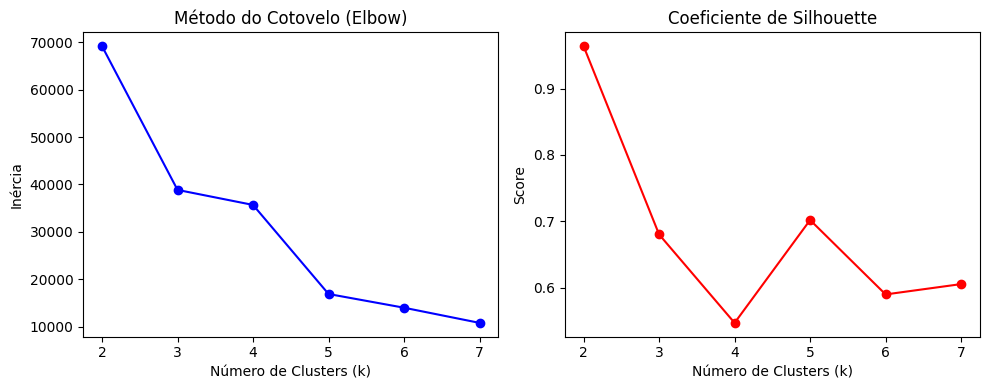

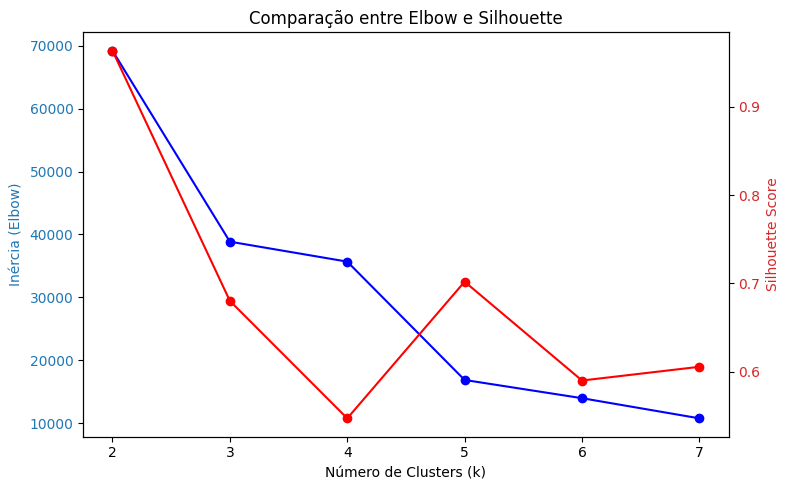

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K = range(2, 8)

# Teste de diferentes valores de k
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# ----- Gráficos separados -----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(K, inertia, 'bo-')
plt.title('Método do Cotovelo (Elbow)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')

plt.subplot(1,2,2)
plt.plot(K, silhouette, 'ro-')
plt.title('Coeficiente de Silhouette')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

# ----- Gráfico combinado -----
fig, ax1 = plt.subplots(figsize=(8,5))

color1 = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (Elbow)', color=color1)
ax1.plot(K, inertia, 'bo-', label='Inércia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color1)

# Segundo eixo y (para Silhouette)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color2)
ax2.plot(K, silhouette, 'ro-', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Comparação entre Elbow e Silhouette')
fig.tight_layout()
plt.show()


### 🔍 Avaliação do Número Ideal de Clusters (k)

Para definir o número mais apropriado de grupos na clusterização, utilizamos duas métricas complementares:  
**o Método do Cotovelo (Elbow)** e o **Coeficiente de Silhouette**.  
Ambos foram testados para valores de *k* variando entre **2 e 7**.

---

#### 📈 1. Método do Cotovelo (Elbow)

O gráfico de **inércia** mostra a soma das distâncias quadradas entre cada ponto e o centróide do seu cluster.  
A curva apresenta uma queda acentuada até **k = 3**, e depois tende a se estabilizar, indicando **diminuição marginal dos ganhos** na compactação dos grupos.

➡️ **Interpretação:** o ponto de inflexão (o “cotovelo”) está em torno de **k = 3**, sugerindo que três clusters representam um bom equilíbrio entre simplicidade e explicação da variância total.

---

#### 📊 2. Coeficiente de Silhouette

O **Silhouette Score** mede a separabilidade entre os clusters, variando entre -1 e 1.  
Valores mais altos indicam melhor definição dos grupos.  
Neste caso:
- O maior valor ocorre em **k = 2 (≈ 0.95)**, mostrando excelente separação,  
- Mas há um **novo pico em k = 5 (≈ 0.70)**, sugerindo que 5 grupos também apresentam boa coesão e separação interna.

➡️ **Interpretação:** embora *k = 2* apresente o melhor score absoluto, ele pode ser **simplista demais** para capturar a diversidade socioeconômica da distribuição de renda.  
O valor **k = 3 ou k = 5** tende a oferecer um **compromisso mais interpretável**, representando perfis distintos de renda, patrimônio e carga tributária.

---

#### ⚖️ 3. Gráfico Combinado — Comparação Direta

O gráfico que combina as duas métricas no mesmo plano reforça essa análise:
- A **inércia estabiliza após k = 3**;  
- O **Silhouette Score tem um segundo ponto alto em k = 5**.

Portanto, os resultados indicam **duas alternativas viáveis** para a modelagem:
- **k = 3 clusters** → estrutura mais simples, ideal para visualização e interpretação didática;  
- **k = 5 clusters** → segmentação mais detalhada, útil para análises regionais e temporais.

---

➡️ A próxima etapa consistirá em aplicar o modelo **KMeans** com os valores de *k* selecionados (3 e 5) e comparar os resultados obtidos em termos de **composição e perfil dos grupos socioeconômicos**.


In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)


### 🧩 Aplicação do Modelo KMeans (k = 3)

Após a análise comparativa entre os métodos **Elbow** e **Silhouette**, foi definido o valor de **k = 3** como o mais adequado para a clusterização inicial.  
Esse número equilibra **simplicidade interpretativa** e **diferenciação entre perfis socioeconômicos**, conforme sugerido pelos gráficos anteriores.

#### ⚙️ O que o código faz:
1. Instancia o modelo `KMeans` com:
   - `n_clusters = 3` → define a criação de três grupos;  
   - `random_state = 42` → garante reprodutibilidade dos resultados.

2. Aplica o método `.fit_predict()` sobre os dados normalizados (`X_scaled`), que:
   - **ajusta o modelo** aos dados (encontra os centróides);  
   - **atribui cada observação** a um cluster.

3. Armazena o resultado na nova coluna `Cluster` do `df_cluster`, associando cada linha (centil) ao grupo correspondente.

#### 💡 Importância:
Com essa operação, cada registro do dataset — representando um **centil de renda por estado e ano** — passa a integrar um dos **três clusters socioeconômicos**, formados a partir de suas semelhanças em:
- **Renda Total**,  
- **Patrimônio Líquido**,  
- **Carga Tributária Efetiva**.

➡️ Essa coluna `Cluster` será utilizada nas próximas etapas para **análise comparativa**, **interpretação dos perfis** e **visualizações tridimensionais**.


In [24]:
# ================================
# Análise dos clusters formados
# ================================

# Médias das variáveis por cluster
df_cluster.groupby("Cluster")[["Renda Total", "Patrimônio Líquido", "Carga Tributária Efetiva"]].mean()


,Renda Total,Patrimônio Líquido,Carga Tributária Efetiva
Cluster,,,
0,571.444978,1346.447521,0.013563
1,1773.050676,4652.439170,0.119670
2,66199.929535,260182.455814,0.109112


### 🧠 Análise dos Clusters Formados (k = 3)

Após a aplicação do modelo **KMeans** com *k = 3*, o algoritmo agrupou os registros em **três clusters socioeconômicos distintos**, com base nas variáveis **Renda Total**, **Patrimônio Líquido** e **Carga Tributária Efetiva**.  
A tabela acima apresenta as médias de cada variável dentro de cada grupo.

---

#### 📊 Interpretação dos Clusters

| Cluster | Perfil socioeconômico | Características principais |
|:--------:|:---------------------|:----------------------------|
| **Cluster 0** | 💼 **Renda média-baixa / baixo patrimônio** | Representa a maioria dos centis inferiores. Apresenta renda e patrimônio reduzidos, com carga tributária efetiva mínima (~1,3%). São contribuintes com menor acúmulo patrimonial e baixa participação tributária. |
| **Cluster 1** | 🏠 **Classe média / patrimônio moderado** | Apresenta renda e patrimônio intermediários. A carga tributária média (~12%) é a mais alta, sugerindo maior proporção de renda tributável. Pode refletir grupos de profissionais liberais e pequenas empresas. |
| **Cluster 2** | 💎 **Alta renda / alto patrimônio acumulado** | Concentra valores extremamente elevados de renda (≈ 66 mil milhões) e patrimônio (≈ 260 mil milhões). Apesar do alto poder econômico, mantém carga tributária média (~11%), indicando possível **regressividade fiscal** — renda elevada com tributação proporcionalmente menor. |

---

#### 💡 Síntese dos resultados:
- Há **três perfis econômicos bem definidos**, confirmando que o modelo com *k = 3* é interpretável e coerente com a realidade socioeconômica brasileira.  
- A **disparidade entre o Cluster 0 e o Cluster 2** evidencia o **abismo de desigualdade** de renda e patrimônio.  
- O **Cluster 1** funciona como grupo intermediário, representando o elo entre a base e o topo da pirâmide econômica.  

➡️ Esses resultados reforçam a validade do modelo, que conseguiu capturar **diferentes estratos de riqueza e tributação** a partir de apenas três variáveis contínuas.  
A próxima etapa será **visualizar graficamente** essas diferenças, por meio de gráficos tridimensionais e de teia (*radar charts*), para interpretar visualmente os perfis de cada cluster.


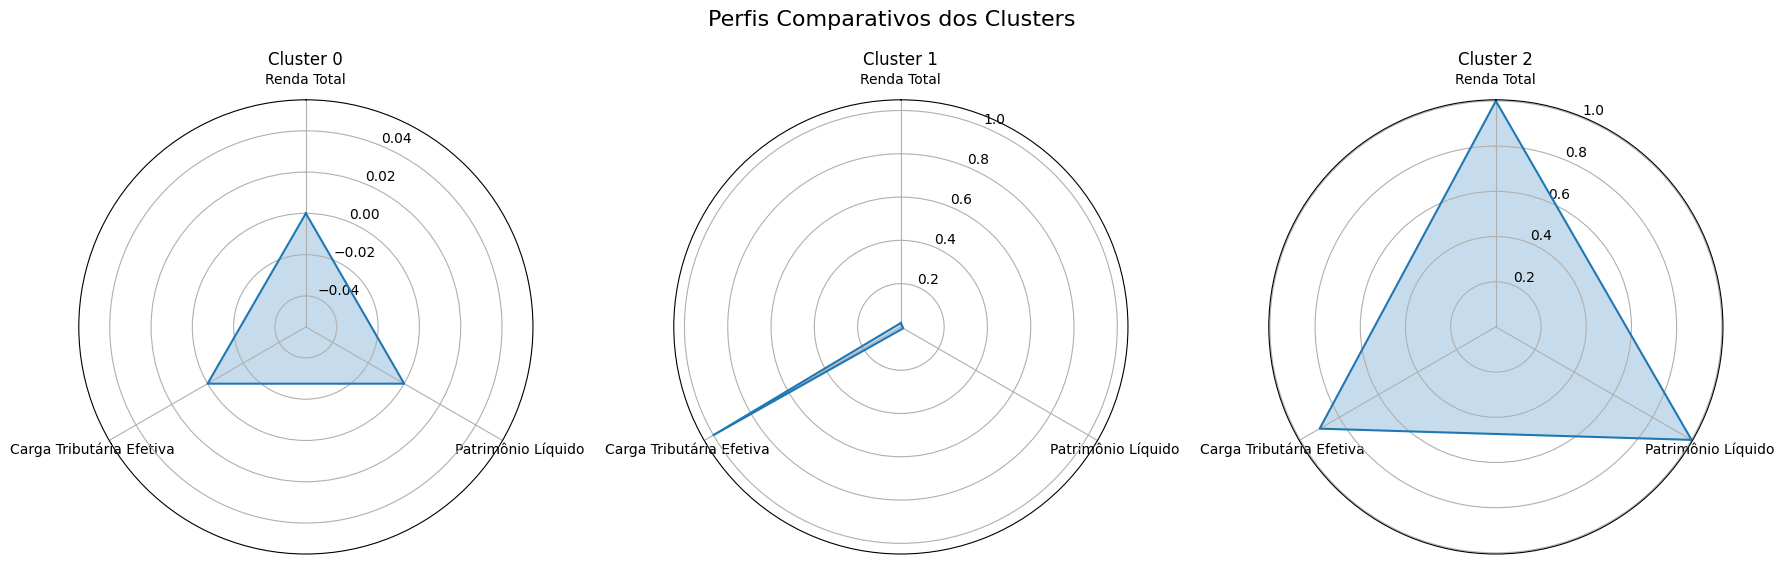

In [25]:
# Normalização global
df_radar = df_cluster.groupby("Cluster")[["Renda Total", "Patrimônio Líquido", "Carga Tributária Efetiva"]].mean()
df_radar_normalizado = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

# Preparar gráfico
import matplotlib.pyplot as plt
import numpy as np

variaveis = df_radar_normalizado.columns.tolist()
num_vars = len(variaveis)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axs = plt.subplots(1, 3, subplot_kw=dict(polar=True), figsize=(18, 6))

for i, cluster_id in enumerate(df_radar_normalizado.index):
    valores = df_radar_normalizado.loc[cluster_id].tolist()
    valores += valores[:1]
    
    ax = axs[i]
    ax.plot(angles, valores, label=f"Cluster {cluster_id}")
    ax.fill(angles, valores, alpha=0.25)
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), variaveis)

plt.suptitle("Perfis Comparativos dos Clusters", fontsize=16)
plt.tight_layout()
plt.show()

### 🕸️ Interpretação do Gráfico de Teia — Perfis Comparativos dos Clusters

O gráfico de teia (ou **radar chart**) mostra o comportamento médio das três variáveis contínuas —  
**Renda Total**, **Patrimônio Líquido** e **Carga Tributária Efetiva** — para cada cluster identificado pelo modelo KMeans (*k = 3*).  
Cada triângulo representa a **assinatura socioeconômica média** de um grupo distinto.

---

#### 📊 **Análise dos Perfis:**

1. **Cluster 0 — Baixa renda e baixo patrimônio (base da pirâmide econômica)**  
   - Apresenta valores **próximos de zero** em todas as dimensões.  
   - Baixa renda total e patrimônio reduzido, com carga tributária quase nula.  
   - Representa a **maior parte dos contribuintes** com pouca capacidade contributiva e mínima acumulação de bens.

2. **Cluster 1 — Classe intermediária (renda média e tributação mais expressiva)**  
   - Carga tributária relativa **significativamente mais alta**, ainda que com renda e patrimônio modestos.  
   - Demonstra um grupo **tributariamente mais onerado**, possivelmente formado por contribuintes formais com rendas estáveis.  
   - Essa configuração reforça a hipótese de **maior peso fiscal sobre a classe média**.

3. **Cluster 2 — Alta renda e alto patrimônio (topo da distribuição)**  
   - Apresenta **valores máximos normalizados (≈ 1.0)** em todas as variáveis.  
   - Elevada renda total e acúmulo patrimonial expressivo, com carga tributária proporcionalmente elevada — embora **menor que a esperada diante do volume de riqueza**.  
   - Representa o grupo econômico de maior concentração de renda e bens.

---

#### 💡 **Síntese Interpretativa:**

O gráfico confirma que o modelo **capturou três perfis socioeconômicos distintos**:
- **Cluster 0:** base econômica, baixa renda e mínima tributação;  
- **Cluster 1:** grupo intermediário, com a maior carga tributária proporcional;  
- **Cluster 2:** elite econômica, concentradora de renda e patrimônio.

A visualização evidencia uma **disparidade estrutural** na distribuição de renda e patrimônio,  
e sugere um comportamento **regressivo da carga tributária** — onde a tributação proporcional tende a ser maior nos grupos de renda intermediária do que entre os mais ricos.

➡️ A seguir, será apresentada a **visualização tridimensional (3D)** da clusterização,  
permitindo observar espacialmente a separação dos grupos formados no espaço de variáveis contínuas.


In [ ]:
# Exemplo de como você pode criar essas colunas (ajuste conforme sua lógica fiscal)
df_cluster["Carga Tributária sobre Consumo"] = (
    df_prep["Imposto Devido [R$ milhões]"] * 0.4  # suposição: 40% do imposto é sobre consumo
)

df_cluster["Carga Tributária sobre Renda"] = (
    df_prep["Imposto Devido [R$ milhões]"] * 0.4  # suposição: 40% sobre renda
)

df_cluster["Carga Tributária sobre Propriedade"] = (
    df_prep["Imposto Devido [R$ milhões]"] * 0.2  # suposição: 20% sobre propriedade
)

In [ ]:
df_cluster.groupby("Cluster")[[
    "Carga Tributária sobre Consumo",
    "Carga Tributária sobre Renda",
    "Carga Tributária sobre Propriedade"
]].mean().round(2)

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.lineplot(data=df_cluster, x="Ano-calendário", y="Renda Total", hue="Cluster")
plt.title("Evolução da Renda Total por Cluster")
plt.grid(True)
plt.show()

In [ ]:
tabela = df_cluster.groupby(["Região", "Cluster"]).size().unstack(fill_value=0)
tabela.plot(kind="bar", stacked=True, figsize=(10,6), colormap="Set2")
plt.title("Distribuição dos Clusters por Região")
plt.ylabel("Número de Observações")
plt.show()

In [ ]:
sns.boxplot(data=df_cluster, x="Cluster", y="Patrimônio Líquido", palette="Set3")
plt.title("Distribuição do Patrimônio Líquido por Cluster")
plt.show()

In [ ]:
import numpy as np
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df_cluster[["Renda Total", "Patrimônio Líquido", "Carga Tributária Efetiva"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre Variáveis Derivadas")
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df_cluster,
    x="Renda Total",
    y="Patrimônio Líquido",
    z="Carga Tributária Efetiva",
    color="Cluster",
    hover_data=["Ano-calendário", "Ente Federativo", "Centil"]
)
fig.show()

In [ ]:
df_radar_regiao = df_cluster.groupby("Região")[["Renda Total", "Patrimônio Líquido", "Carga Tributária Efetiva"]].mean()